# 関数設計

96
96


KeyError: 'sus1'

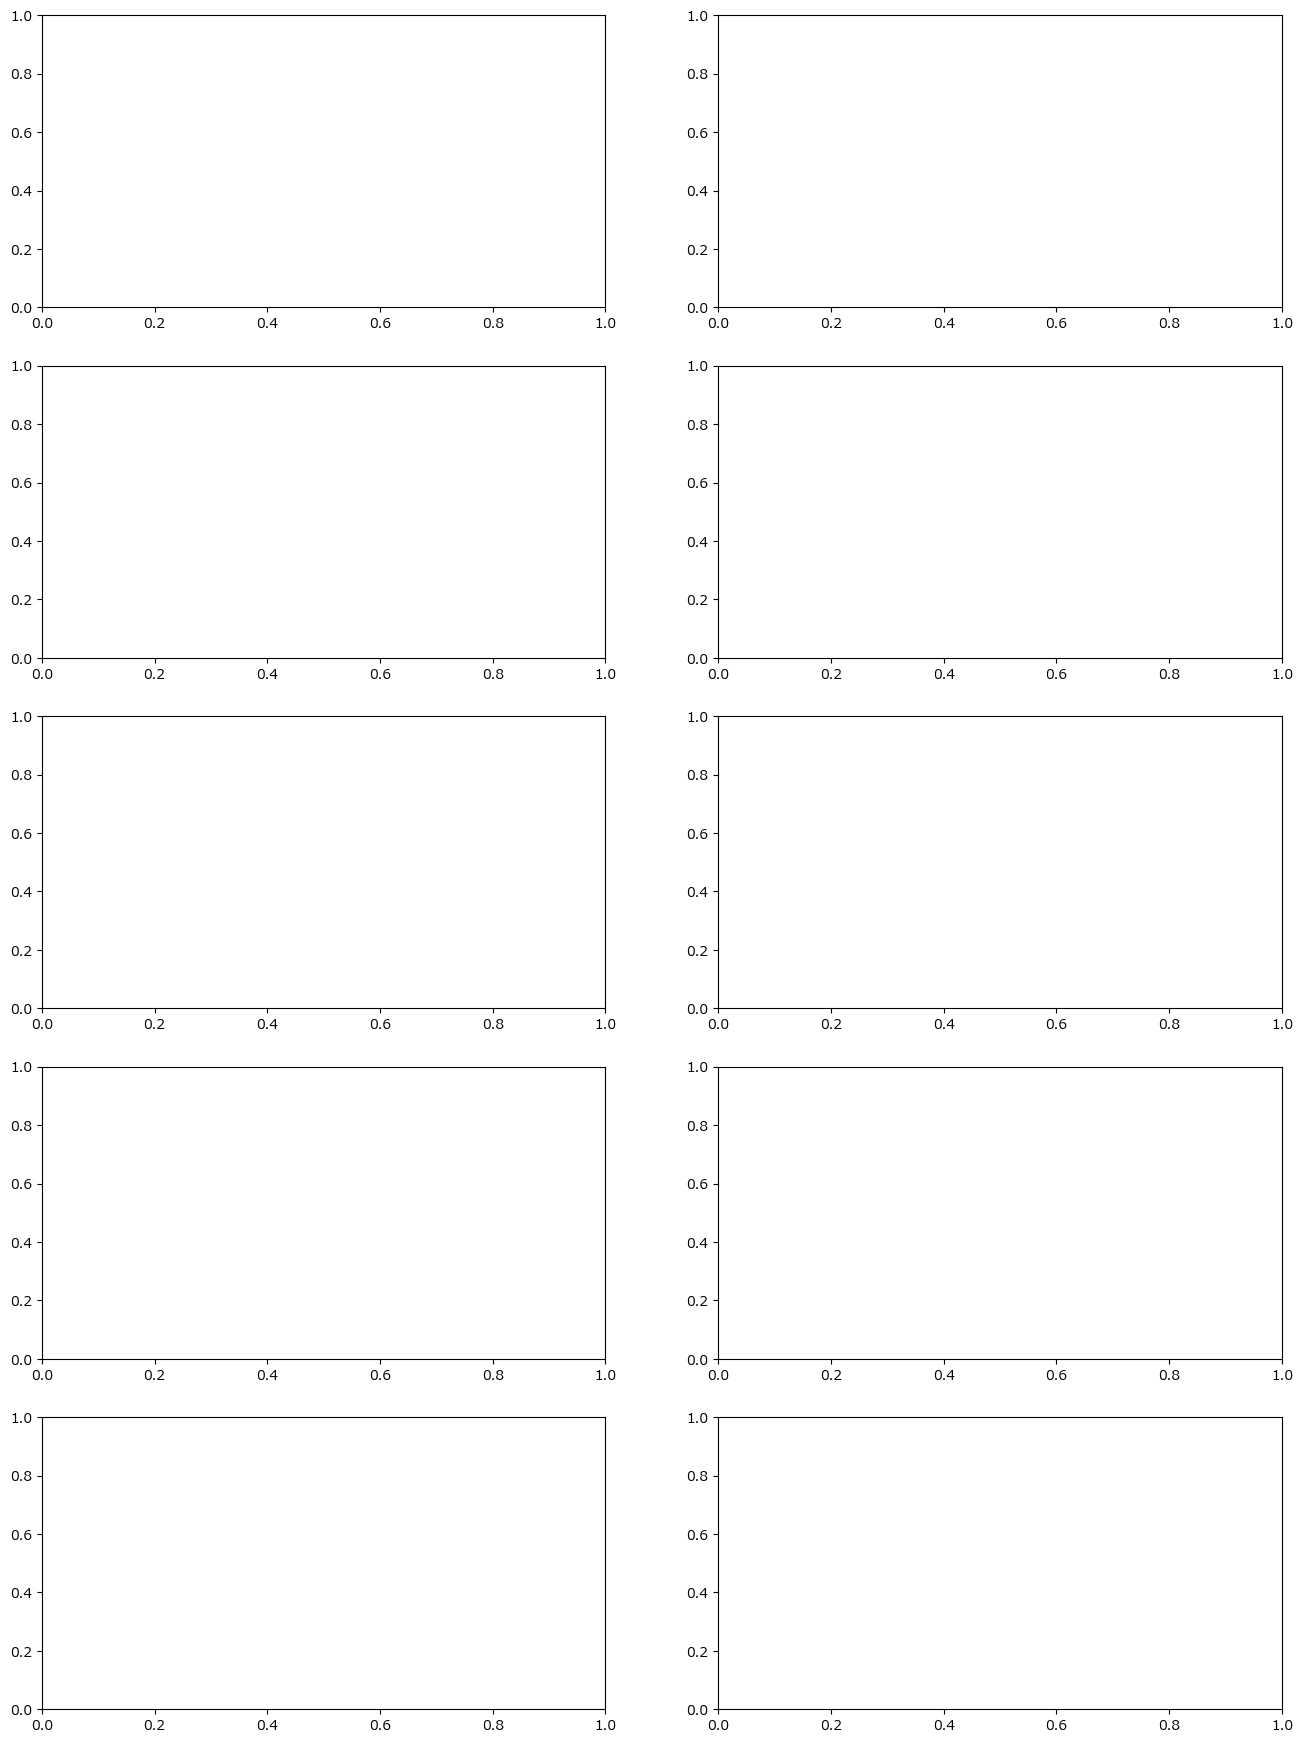

In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kruskal
import scikit_posthocs as sp
import matplotlib
from scipy.stats import shapiro
import warnings
from scipy.stats import friedmanchisquare
import scikit_posthocs as sp

warnings.filterwarnings("ignore", category=FutureWarning)

# 日本語フォント設定
matplotlib.rcParams['font.family'] = 'Meiryo'



# --- 定数定義 ---
CATEGORY_COLUMNS = {
    'sus':     list(range(1, 11)),   # SUS 1–10
    'tam':     list(range(11, 14)),  # TAM 11–13
    'method_trust':   list(range(14, 18)),  # Trust 14–17
    'system_trust':  list(range(18, 29)),  # Trust2 18–28
    'nasa':    list(range(29, 35)),  # NASA-TLX 29–37
}
PARTICIPANT_COL = 38
CONDITION_COL   = 39
INVALID_IDS     = ['0', 'TEST', 'OLD_P1',"", "OLD_P2",  "P1_OLD","P2_OLD","P3_OLD","P4_OLD","P5_OLD","P6_OLD", ]

CONDITION_MAP = {
    1: "SpatialReference",
    2: "Pointing+SpatialReference",
    3: "Pointing",
    4: "Label"
}
 # 特定のIDのみを残す場合（必要なときにコメントアウトを外す）



# --- スコア計算 ---
def calc_sus_score(raw: list[int]) -> float:
    adj = [(s - 1) if i % 2 == 0 else (5 - s) for i, s in enumerate(raw)]
    return sum(adj) * 2.5

def compute_mean(vals: list[int]) -> float:
    return np.mean(vals)

def reverse_scoring(df: pd.DataFrame) -> pd.DataFrame:
    df['system_trust'] = df['system_trust'].apply(lambda v: [6 - x if i in (8,9) else x for i, x in enumerate(v)])
    df['nasa']   = df['nasa'].apply(lambda v: [6 - x if i == 3 else x for i, x in enumerate(v)])
    return df

# --- 統計検定用 ---
def run_kruskal(label: str, df: pd.DataFrame) -> tuple[float, float]:
    groups = [df[df['condition'] == c][label] for c in CONDITION_MAP.values()]
    return kruskal(*groups)

def check_normality(label: str, df: pd.DataFrame):
    print(f"\n🔍 正規性の検定（Shapiro-Wilk）: {label}")
    for cond in CONDITION_MAP.values():
        vals = df[df['condition'] == cond][label].dropna()  # ← NaNを除く
        n = len(vals)
        if n < 3:
            print(f"{label} - {cond}: ⚠ データ数不足（{n} 件）→ 検定スキップ")
            continue
        try:
            stat, p = shapiro(vals)
            mark = "✅ 正規性あり" if p > 0.05 else "❌ 正規性なし"
            print(f"{label} - {cond}: W={stat:.3f}, p={p:.4f} {mark}")
        except Exception as e:
            print(f"{label} - {cond}: ⚠ 検定失敗 ({e})")


# --- データ読み込み & 前処理 ---

def load_and_preprocess(filepath: str) -> pd.DataFrame:
    df = pd.read_csv(filepath, encoding='utf-8')


    
    # 参加者ID・条件情報の処理
    df['participant_id'] = df.iloc[:, PARTICIPANT_COL].astype(str)
    df['condition'] = df.iloc[:, CONDITION_COL].astype(int)

    # 無効なID除外
    df = df[~df['participant_id'].isin(INVALID_IDS)]
 
    print(len(df["participant_id"]))
    # df = df[df['participant_id'].isin(["P3"])]
    print(len(df))
    df = df.reset_index(drop=True)

    # SUS, TAM, Trust, Trust2, NASA などのスコア用リスト列を作成
    for key, cols in CATEGORY_COLUMNS.items():
        df[key] = df.iloc[:, cols].apply(lambda r: r.astype(int).tolist(), axis=1)
    
    
    return df

def kruskal_eta_squared(H: float, k: int, n: int) -> float:
    return (H - k + 1) / (n - k)

# --- メイン ---
def main():
    # データ読み込み・前処理
    df = load_and_preprocess('SurvayResult.csv')
    df = reverse_scoring(df)

    # スコア DataFrame 作成
    metrics = {
        'SUS':     ('sus',    calc_sus_score, 0, 100),
        'TAM':     ('tam',    compute_mean,   1,   7),
        'MethodTrust':   ('method_trust',  compute_mean,   1,   7),
        'SystemTrust':  ('system_trust', compute_mean,   1,   7),
        'NASA-TLX':('nasa',   compute_mean,   1,   7),
    }
    dfs = {}
    for name, (key, func, ymin, ymax) in metrics.items():
        dfs[name] = pd.DataFrame({
            'participant_id': df['participant_id'],
            'condition':      df['condition'],
            name:              df[key].apply(func)
        })

    # 条件ラベル適用
    ordered_conditions = ["SpatialReference", "Pointing+SpatialReference", "Pointing", "Label"]
    for dfm in dfs.values():
        dfm['condition'] = dfm['condition'].map(CONDITION_MAP)

    # 🔽 条件の並び順を明示的に指定
    ordered_conditions = ["SpatialReference", "Pointing+SpatialReference", "Pointing", "Label"]
    for dfm in dfs.values():
        dfm['condition'] = pd.Categorical(dfm['condition'], categories=ordered_conditions, ordered=True)
    # 1. 基本プロット: 箱ひげ＋スウォーム & 平均±SEバー
    fig1, axes1 = plt.subplots(len(metrics), 2, figsize=(14, 5*len(metrics)))
    for i, (name, dfm) in enumerate(dfs.items()):
        ymin, ymax = metrics[name][2], metrics[name][3]
        # 箱ひげ＋スウォーム
        ax = axes1[i, 0]
        sns.boxplot(data=dfm, x='condition', y=name, palette='pastel', ax=ax)
        sns.swarmplot(data=dfm, x='condition', y=name, color='k', alpha=0.6, ax=ax)
        ax.set(title=f"{name} の条件別比較", ylim=(ymin, ymax))
        # 平均±SEバー
        ax2 = axes1[i, 1]
        means = dfm.groupby('condition')[name].mean()
        sems  = dfm.groupby('condition')[name].sem()
        ax2.bar(means.index, means, yerr=sems, capsize=5)
        ax2.set(title=f"{name} 平均 ± SE", ylim=(ymin, ymax))
    plt.tight_layout(); plt.suptitle('条件別ユーザビリティ・受容性評価', y=1.02)
    plt.savefig('survey_plots.png', dpi=300)

    # 2. 統計検定 & 結果表示
    print()
    stats = {}
    for name in ['SUS','TAM','MethodTrust','SystemTrust']:
        stat, p = run_kruskal(name, dfs[name])
        has_significance = p < 0.05
        mark = "✅ 有意差あり" if has_significance else "❌ 有意差なし"
        print(f"{name}: H={stat:.3f}, p={p} {mark}")
        stats[name] = (stat, p)

        # 有意差があればDunn事後検定
        if has_significance:
            print("→ Dunnの事後検定（Bonferroni補正）結果:")
            print(sp.posthoc_dunn(dfs[name], val_col=name, group_col='condition', p_adjust='bonferroni'))
            print()
    # 各条件（行） × 各指標（列）の平均スコアを作成
    summary = pd.DataFrame(
    {
        metric: [
            dfs[metric][dfs[metric]['condition'] == cond][metric].mean()
            for cond in CONDITION_MAP.values()
        ]
        for metric in ['SUS', 'TAM', 'MethodTrust', 'SystemTrust']
    },
        index=CONDITION_MAP.values()  # 行名を条件のラベルに
    )

    # 小数点以下2桁で丸めて表示
    print(summary.round(2))

    # 4. 効果量 η² を表示
    print("\n効果量 η²（Kruskal-Wallis）:")
    for name in ['SUS','TAM','Trust','SystemTrust']:
        H, p = stats[name]
        n = len(dfs[name])  # データ数（NaN除外してないならOK）
        k = dfs[name]['condition'].nunique()
        eta2 = kruskal_eta_squared(H, k, n)
        print(f"{name}: η² = {eta2:.3f}")

    
    run_friedman_nemenyi(dfs)

    # 3. 統計結果付きボックスプロット
    fig2, axes2 = plt.subplots(2, 2, figsize=(12, 10))
    for ax, name in zip(axes2.flat, ['SUS','TAM','MethodTrust','SystemTrust']):
        dfm = dfs[name]
        stat, p = stats[name]
        sns.boxplot(data=dfm, x='condition', y=name, palette='pastel', ax=ax)
        ax.set_title(f"{name} (H={stat:.2f}, p={p})")
        ax.set_xlabel(''); ax.set_ylabel(name)
    plt.tight_layout(); plt.suptitle('統計検定結果付き分布図', y=1.02)
    plt.savefig('stats_boxplots.png', dpi=300)
    plt.show()



In [100]:


from scipy.stats import friedmanchisquare
import scikit_posthocs as sp
import itertools

def run_friedman_nemenyi(dfs, alpha=.05):

    results = {}

    for metric, dfm in dfs.items():         # ← ループを dfs のキーに合わせても OK
        wide = dfm.pivot(index='participant_id',
                         columns='condition',
                         values=metric).dropna()
        try:
            stat, p = friedmanchisquare(*[wide[c] for c in wide.columns])
        except Exception as e:
            print(f"{metric}: Friedman error → {e}")
            continue

        print(f"{metric}: χ²={stat:.3f}, p={p:.4f}")
        if p >= alpha:
            continue        # 有意差なければスキップ

        # ---- Nemenyi ----
        post = sp.posthoc_nemenyi_friedman(wide)
        sig_pairs = []
        sig_pvals = []
        for i, j in itertools.combinations(range(len(post)), 2):
            pval = post.iloc[i, j]
            if pval < alpha:
                a = post.index[i]
                b = post.columns[j]
                sig_pairs.append((a, b))
                sig_pvals.append(pval)

        results[metric] = dict(pairs=sig_pairs, pvals=sig_pvals)

    return results

import math
import matplotlib.pyplot as plt
import seaborn as sns

def visualize_nemenyi_heatmaps(nemenyi_results: dict,
                               max_cols: int = 3,
                               figsize_per_ax: tuple = (5, 4)):
    """
    nemenyi_results : {'SUS':df, 'TAM':df, ...}
      → df は Nemenyi の p 値マトリクス (DataFrame)
    max_cols        : 1 行に並べる最大列数
    figsize_per_ax  : (横,縦) 1 枚あたりのサイズ
    """
    n = len(nemenyi_results)
    if n == 0:
        print("⚠ Nemenyi結果が空です")
        return

    # 行数・列数を自動決定
    ncols = min(max_cols, n)
    nrows = math.ceil(n / ncols)

    fig_w  = figsize_per_ax[0] * ncols
    fig_h  = figsize_per_ax[1] * nrows
    fig, axes = plt.subplots(nrows, ncols, figsize=(fig_w, fig_h),
                             squeeze=False)  # 常に 2D 配列

    # flatten して for ループ
    axes_flat = axes.flatten()

    for ax, (metric, df) in zip(axes_flat, nemenyi_results.items()):
        sns.heatmap(df, annot=True, fmt=".3f", cmap="coolwarm_r",
                    cbar_kws=dict(label="p 値"),
                    linewidths=.5, square=True, ax=ax,
                    vmin=0, vmax=1)
        ax.set_title(f"{metric}  Nemenyi")

    # 余った空 ax を消す
    for ax in axes_flat[len(nemenyi_results):]:
        ax.axis("off")

    plt.suptitle("Nemenyi 事後検定結果ヒートマップ", fontsize=18, y=1.02)
    plt.tight_layout()
    plt.savefig("nemenyi_heatmaps.png", dpi=300, bbox_inches="tight")
    plt.show()


88
88

SUS: H=34.468, p=1.5782178928105522e-07 ✅ 有意差あり
→ Dunnの事後検定（Bonferroni補正）結果:
                           SpatialReference  Pointing+SpatialReference  \
SpatialReference                   1.000000               1.930567e-03   
Pointing+SpatialReference          0.001931               1.000000e+00   
Pointing                           0.089717               1.000000e+00   
Label                              0.501103               5.966122e-07   

                           Pointing         Label  
SpatialReference           0.089717  5.011028e-01  
Pointing+SpatialReference  1.000000  5.966122e-07  
Pointing                   1.000000  1.875066e-04  
Label                      0.000188  1.000000e+00  

TAM: H=30.119, p=1.302481135422578e-06 ✅ 有意差あり
→ Dunnの事後検定（Bonferroni補正）結果:
                           SpatialReference  Pointing+SpatialReference  \
SpatialReference                   1.000000                   0.000287   
Pointing+SpatialReference          0.000287                 

KeyError: 'Trust'

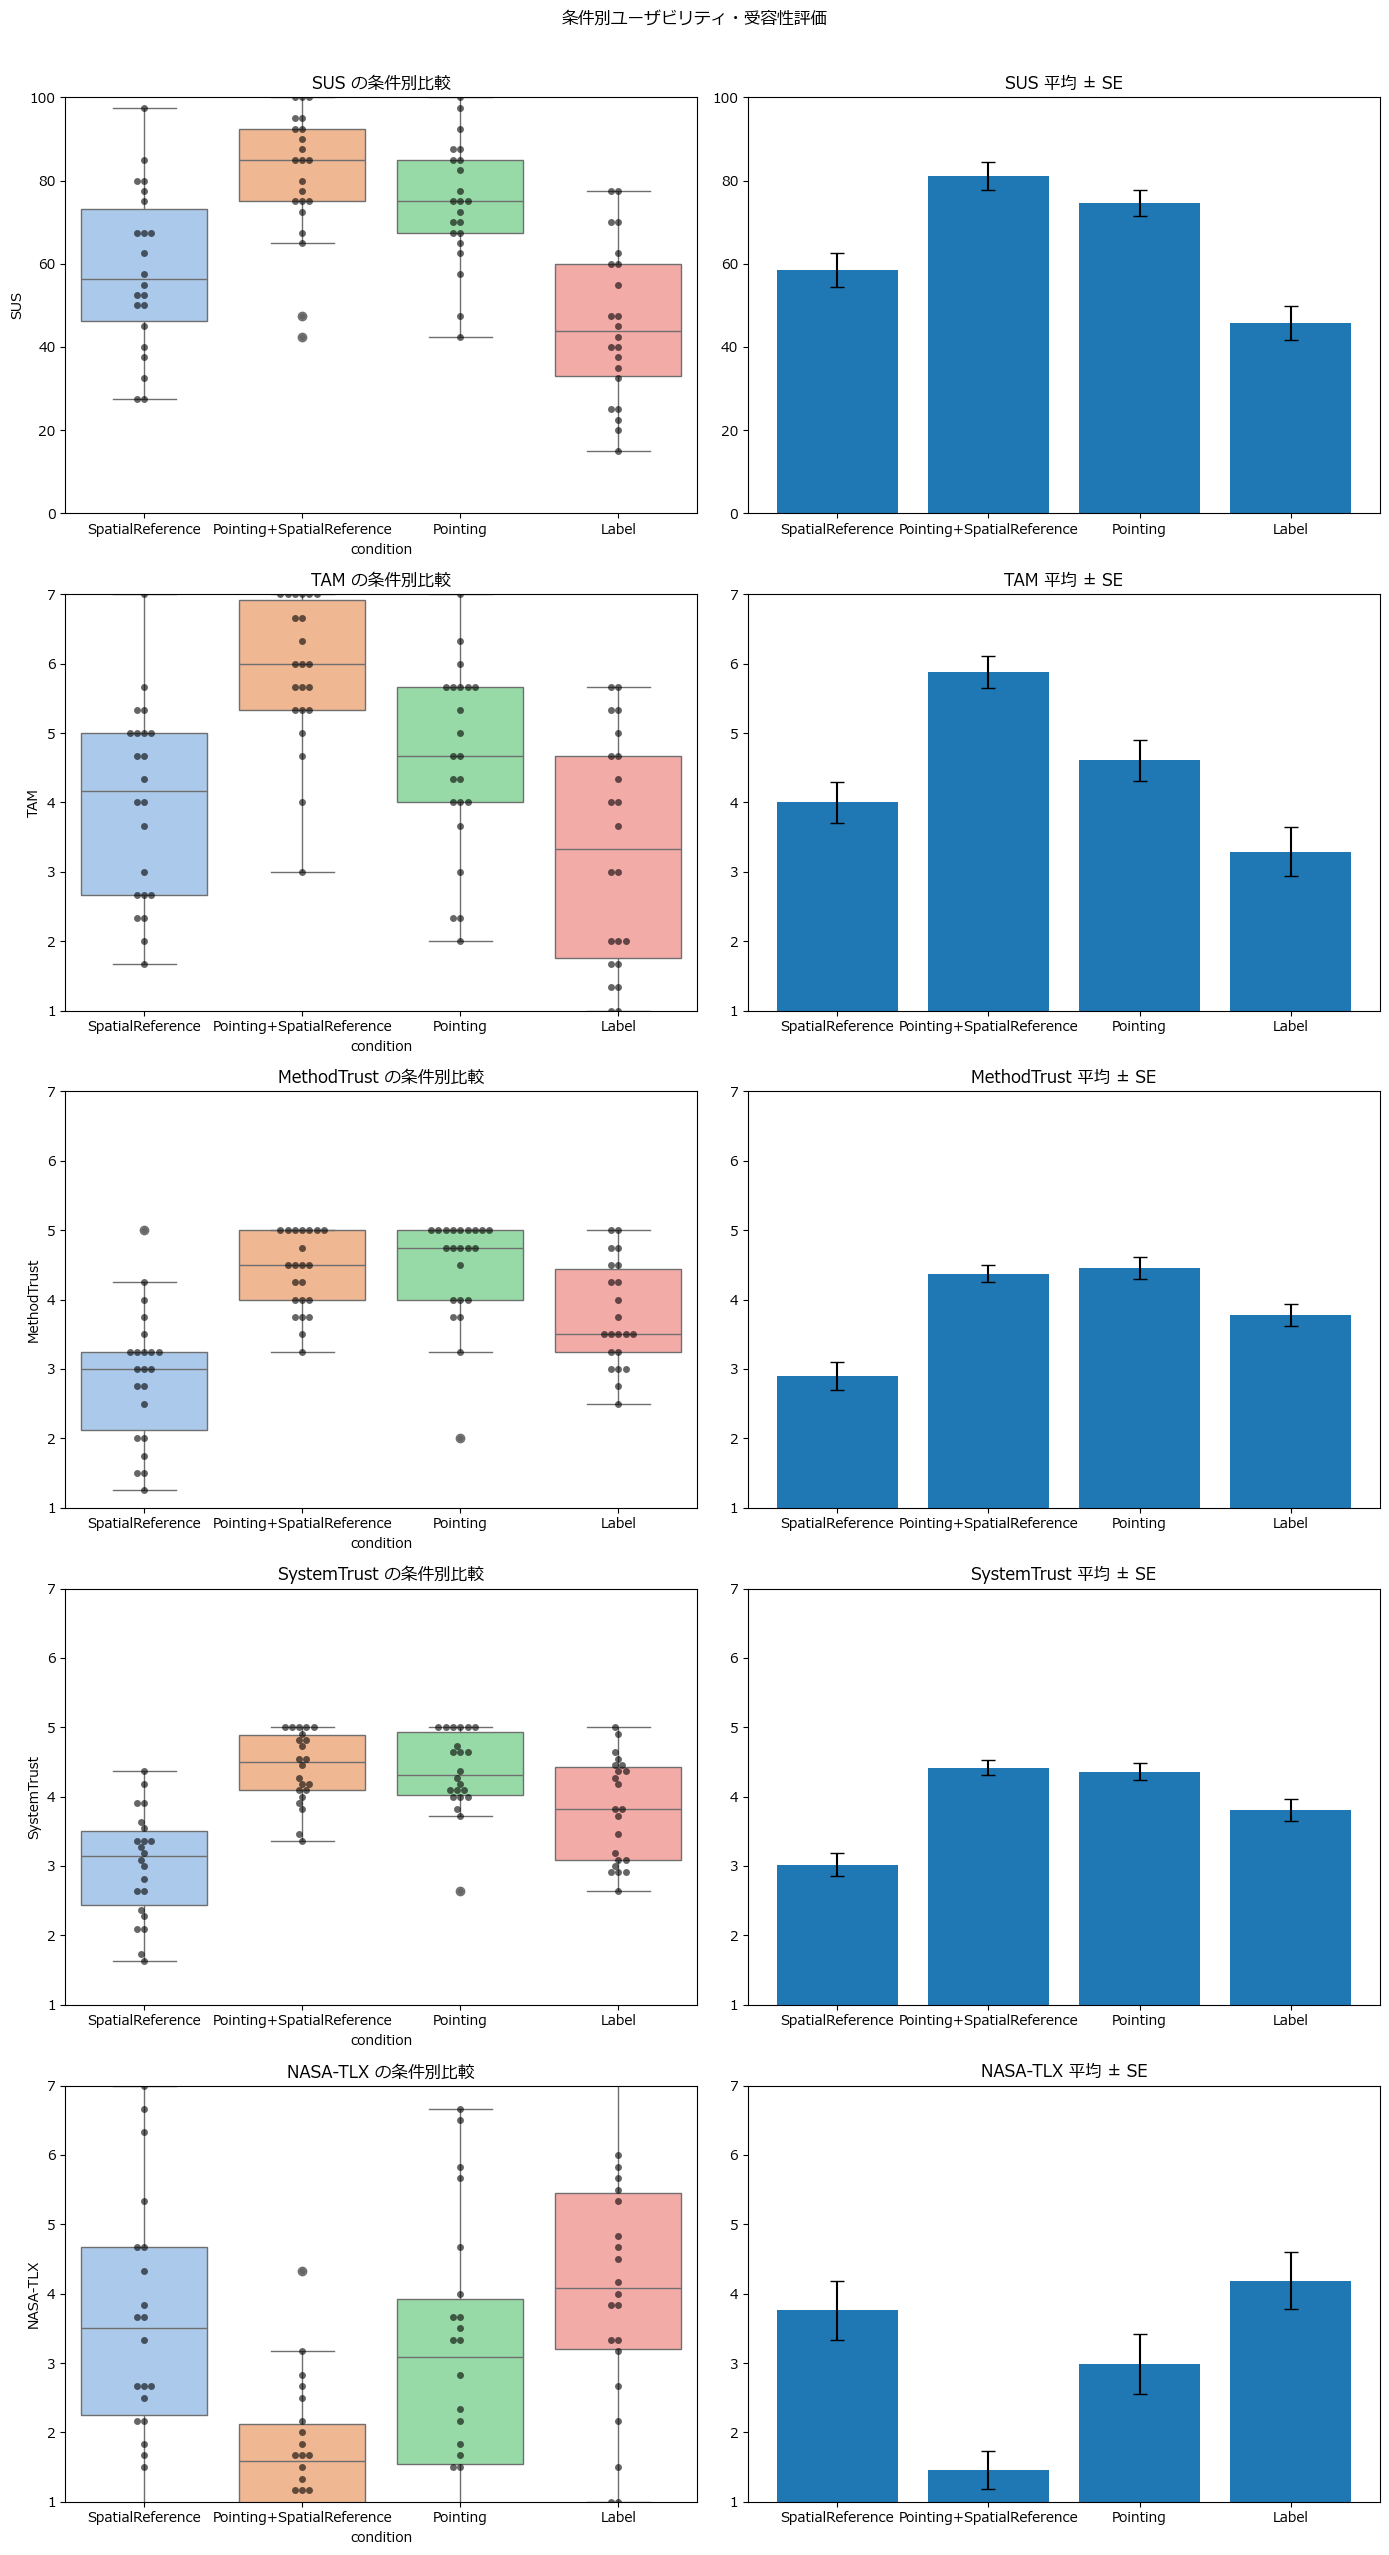

In [9]:
main()

In [ ]:
df['condition'] = df['condition'].map(CONDITION_MAP)

# データ読み込み・前処理

In [101]:
# データ読み込み・前処理
df = load_and_preprocess('SurvayResult.csv')
df = reverse_scoring(df)

INVALID_IDS     = ['0', 'TEST', 'OLD_P1',"", "OLD_P2",  "P1_OLD","P2_OLD","P3_OLD","P4_OLD","P5_OLD","P6_OLD", ]
df = df[~df['participant_id'].isin(INVALID_IDS)]
CATEGORY_COLUMNS = {
    'sus':     list(range(1, 11)),   # SUS 1–10
    'tam':     list(range(11, 14)),  # TAM 11–13
    'method_trust':   list(range(14, 18)),  # Trust 14–17
    'system_trust':  list(range(18, 29)),  # Trust2 18–28
    'nasa':    list(range(29, 35)),  # NASA-TLX 29–37
}
survay_score  = {}
survay_questions = {}

for key, cols in CATEGORY_COLUMNS.items():
    # スライスは cols[0] から cols[-1]+1 まで（末尾を含むには+1が必要）
    cleaned_columns = [re.sub(r'\n（.*?）', '', col) for col in df.columns[cols[0]:cols[-1]+1]]
    survay_questions[key] = cleaned_columns


for key, cols in CATEGORY_COLUMNS.items():
    survay_score[key] = df.iloc[:, cols].apply(lambda r: r.astype(int).tolist(), axis=1)




# スコア DataFrame 作成
metrics = {
    'SUS':     ('sus',    calc_sus_score, 0, 100),
    'TAM':     ('tam',    compute_mean,   1,   7),
    'MethodTrust':   ('method_trust',  compute_mean,   1,   7),
    'SystemTrust':  ('system_trust', compute_mean,   1,   7),
    'NASA-TLX':('nasa',   compute_mean,   1,   7),
}
dfs = {}
for name, (key, func, ymin, ymax) in metrics.items():
    dfs[name] = pd.DataFrame({
        'participant_id': df['participant_id'],
        'condition':      df['condition'],
        name:              df[key].apply(func)
    })

# 条件ラベル適用
ordered_conditions = ["SpatialReference", "Pointing+SpatialReference", "Pointing", "Label"]
for dfm in dfs.values():
    dfm['condition'] = dfm['condition'].map(CONDITION_MAP)

96
96


# 結果の可視化

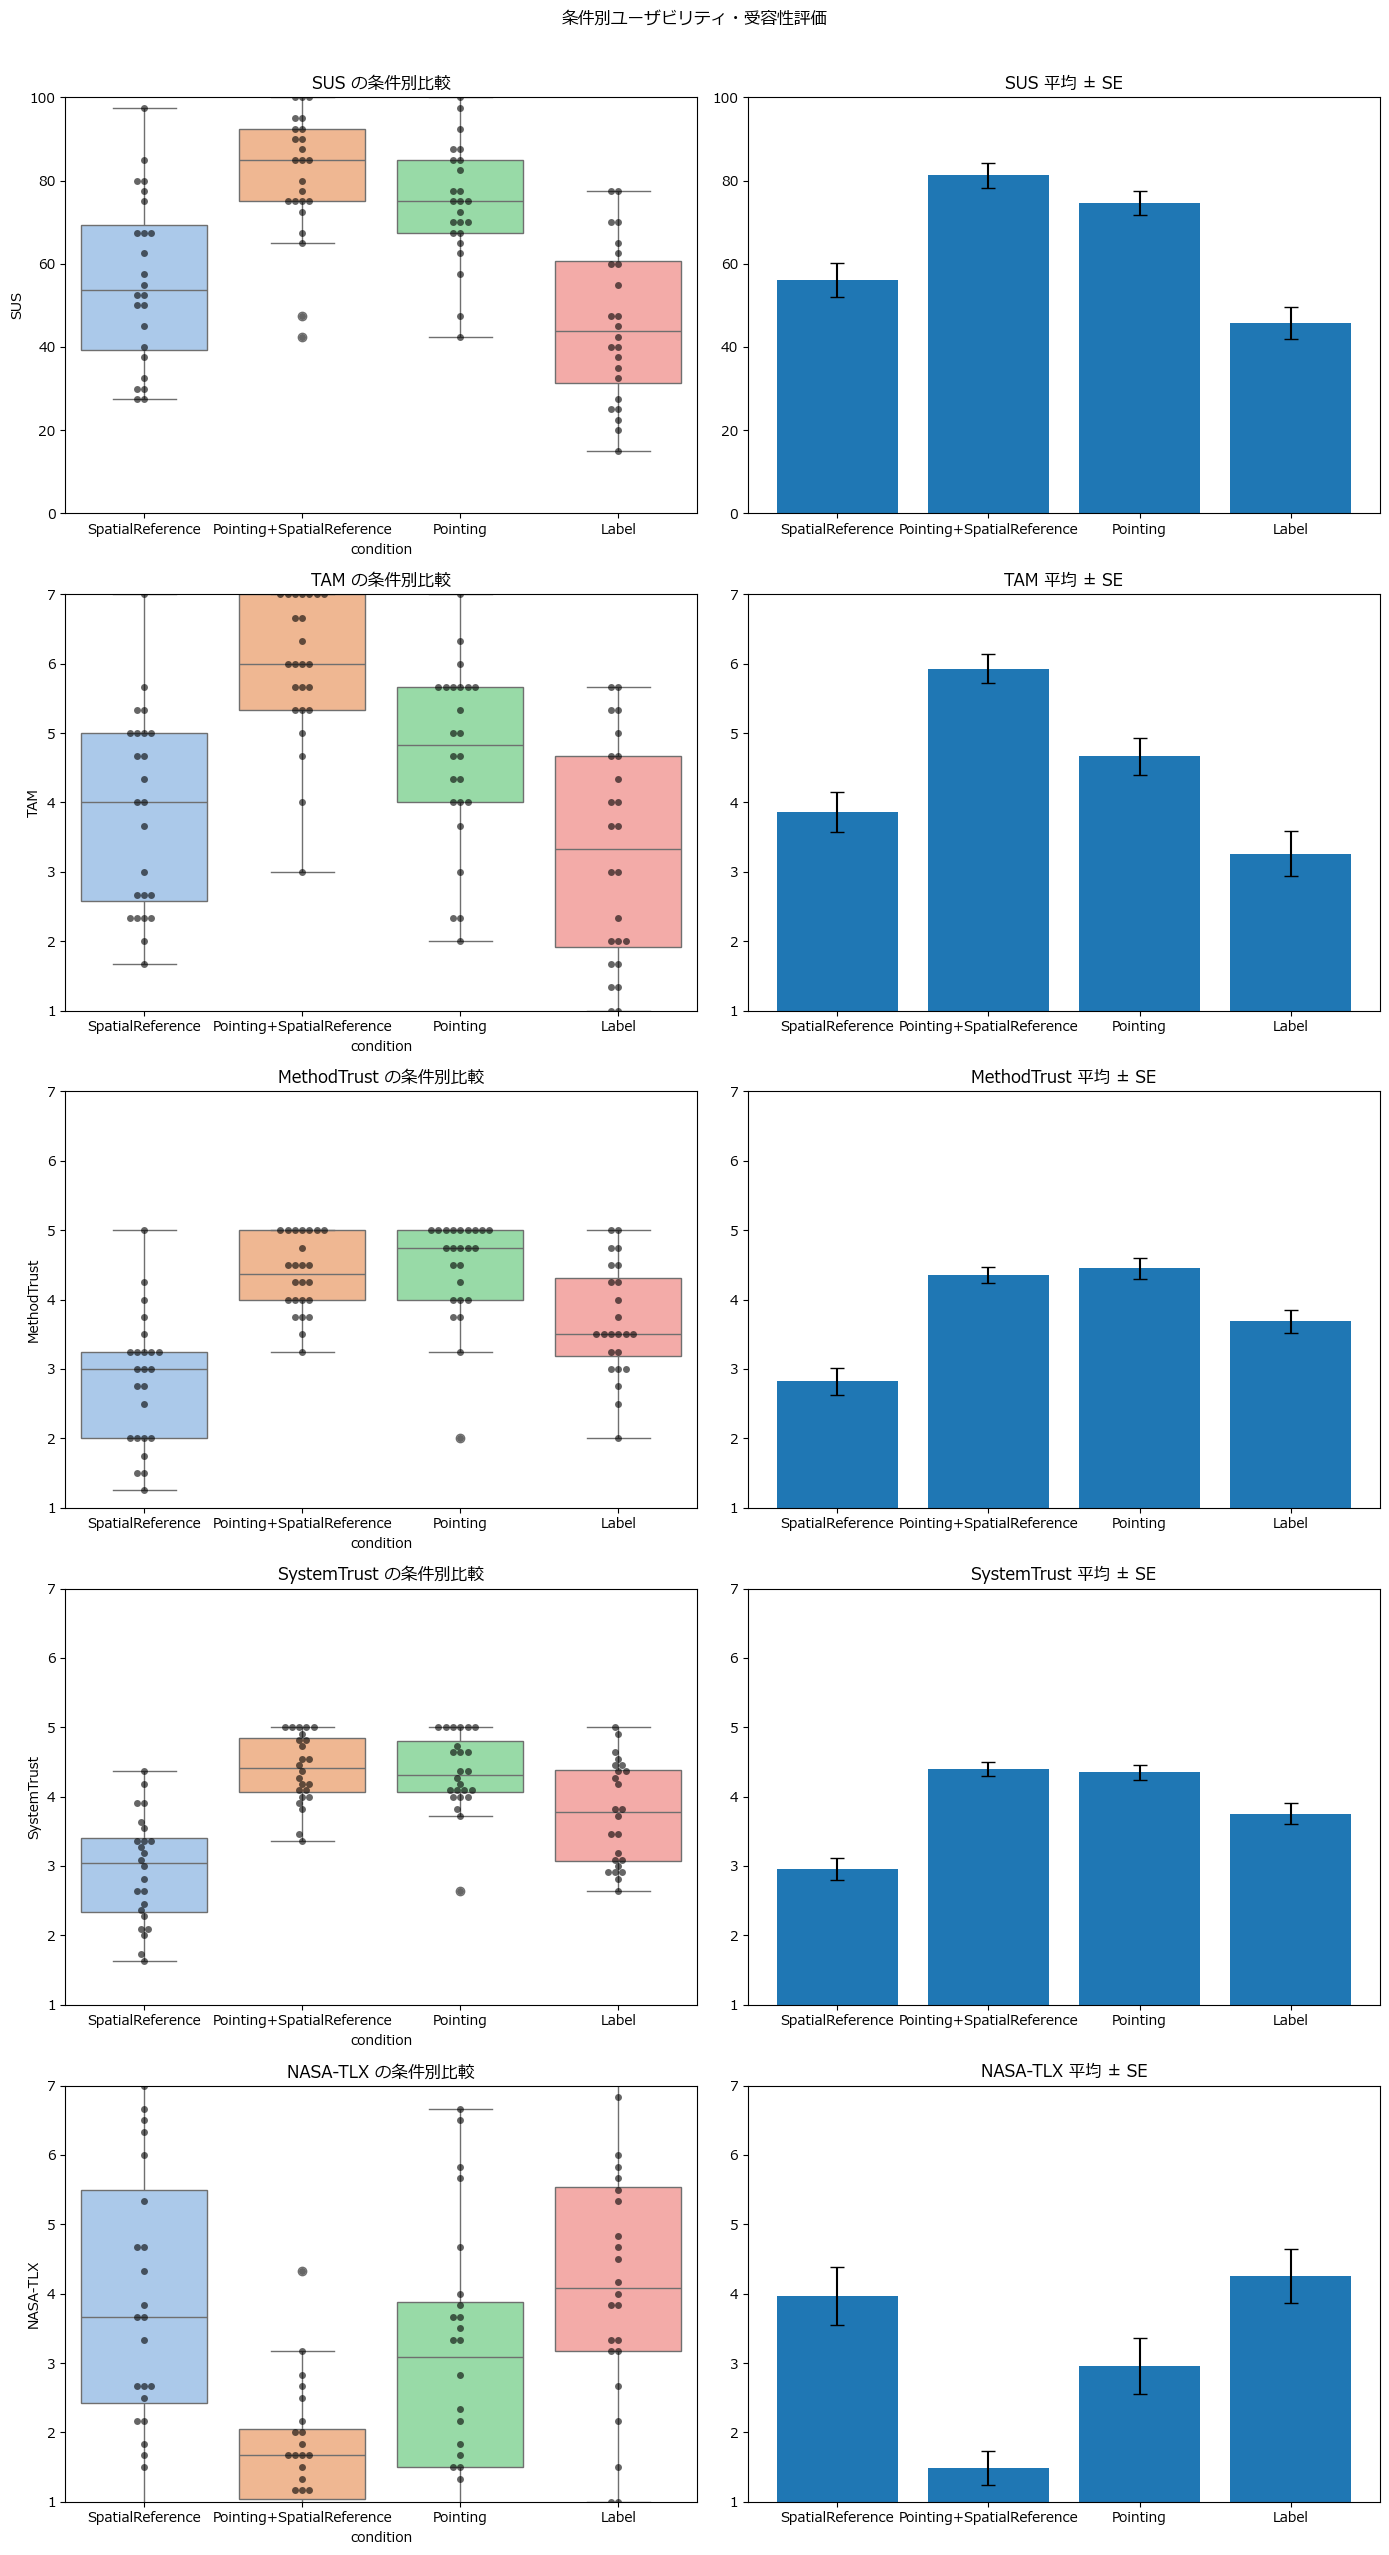

In [98]:
# 🔽 条件の並び順を明示的に指定
ordered_conditions = ["SpatialReference", "Pointing+SpatialReference", "Pointing", "Label"]
for dfm in dfs.values():
    dfm['condition'] = pd.Categorical(dfm['condition'], categories=ordered_conditions, ordered=True)
# 1. 基本プロット: 箱ひげ＋スウォーム & 平均±SEバー
fig1, axes1 = plt.subplots(len(metrics), 2, figsize=(14, 5*len(metrics)))
for i, (name, dfm) in enumerate(dfs.items()):
    ymin, ymax = metrics[name][2], metrics[name][3]
    # 箱ひげ＋スウォーム
    ax = axes1[i, 0]
    sns.boxplot(data=dfm, x='condition', y=name, palette='pastel', ax=ax)
    sns.swarmplot(data=dfm, x='condition', y=name, color='k', alpha=0.6, ax=ax)
    ax.set(title=f"{name} の条件別比較", ylim=(ymin, ymax))
    # 平均±SEバー
    ax2 = axes1[i, 1]
    means = dfm.groupby('condition')[name].mean()
    sems  = dfm.groupby('condition')[name].sem()
    ax2.bar(means.index, means, yerr=sems, capsize=5)
    ax2.set(title=f"{name} 平均 ± SE", ylim=(ymin, ymax))
plt.tight_layout(); plt.suptitle('条件別ユーザビリティ・受容性評価', y=1.02)
plt.savefig('survey_plots.png', dpi=300)


# Friedman統計検定・結果

SUS: χ²=44.161, p=0.0000
TAM: χ²=32.429, p=0.0000
MethodTrust: χ²=39.968, p=0.0000
SystemTrust: χ²=43.349, p=0.0000
NASA-TLX: χ²=32.046, p=0.0000


ValueError: Must pass 2-d input. shape=()

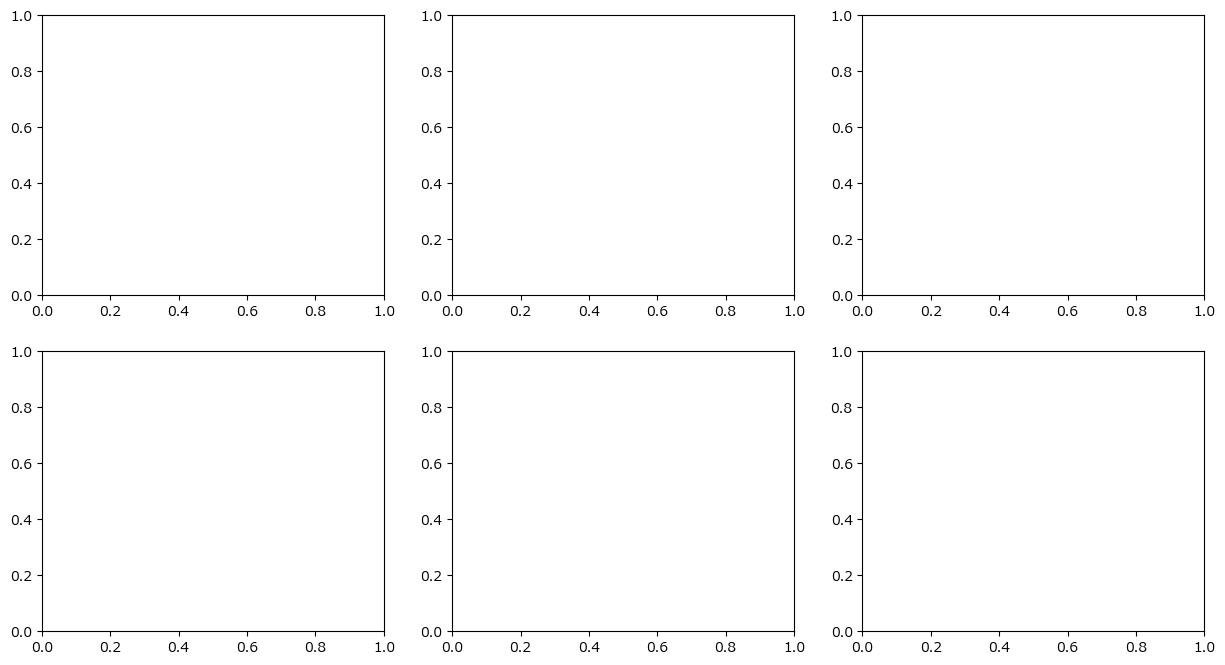

In [102]:
nemenyi_results = run_friedman_nemenyi(dfs)  # ← 結果を受け取る
visualize_nemenyi_heatmaps(nemenyi_results)  # ← 可視化する


In [68]:

print(survay_score["sus"])


0     [2, 1, 4, 1, 5, 1, 5, 2, 2, 1]
1     [5, 1, 5, 1, 5, 1, 5, 1, 5, 1]
2     [4, 4, 5, 1, 5, 1, 5, 2, 5, 1]
3     [4, 1, 5, 1, 5, 1, 3, 2, 4, 5]
4     [4, 2, 4, 3, 4, 1, 4, 3, 4, 4]
                   ...              
91    [5, 1, 5, 2, 5, 2, 5, 2, 5, 2]
92    [2, 2, 4, 2, 3, 2, 3, 2, 4, 2]
93    [2, 4, 2, 4, 3, 4, 2, 4, 2, 3]
94    [4, 2, 4, 2, 4, 2, 4, 2, 4, 2]
95    [4, 2, 5, 2, 3, 2, 5, 2, 4, 2]
Length: 96, dtype: object


ERROR: Could not find a version that satisfies the requirement install (from versions: none)
ERROR: No matching distribution found for install


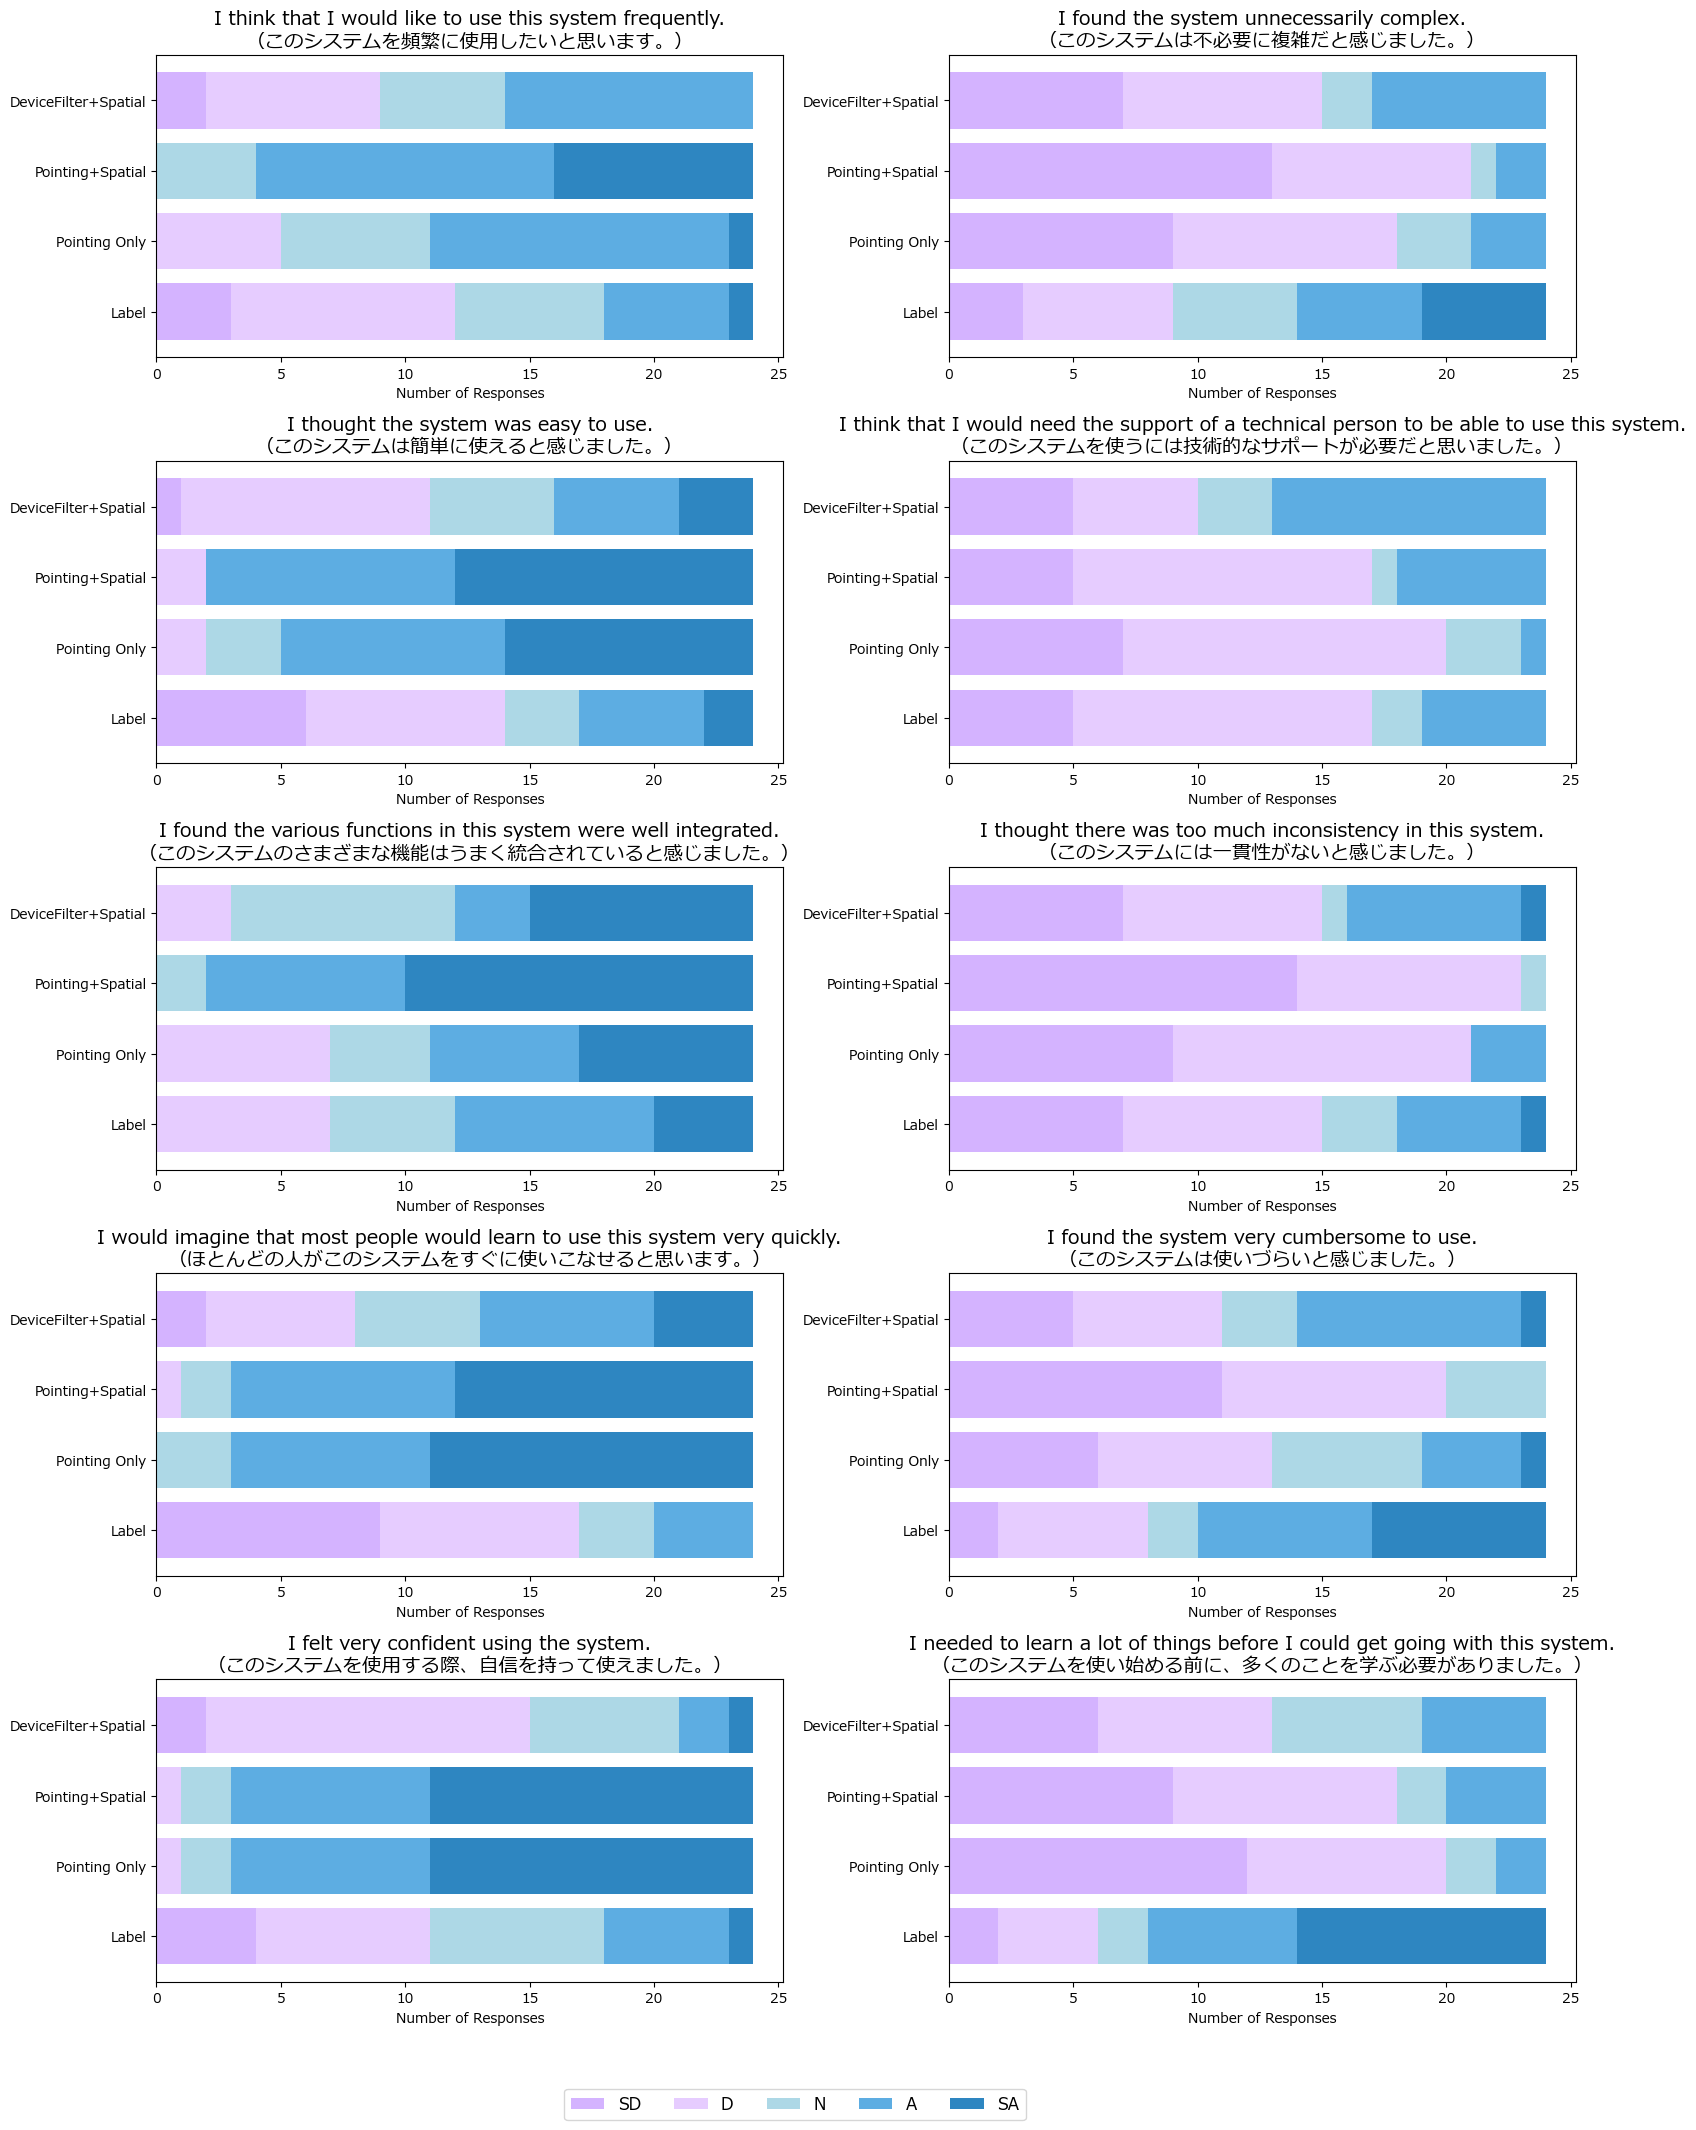

In [93]:
# df_result は既に読み込み＆前処理済みとします


# Condition の値と DataFrame 名の対応例
# 1: DeviceFilterAgent + SpatialReasoningAgent → df_spatial
# 2: Pointing + SpatialReasoningAgent      → df_ptSpatial
# 3: Pointing Only                         → df_point
# 4: Label                                 → df_label

df_spatial    = df_result[df_result['Condition'] == 1].copy()
df_ptSpatial  = df_result[df_result['Condition'] == 2].copy()
df_point      = df_result[df_result['Condition'] == 3].copy()
df_label      = df_result[df_result['Condition'] == 4].copy()

sus_cols = df_result.columns[1:11]


# Condition ごとに分けた各 DataFrame から、SUS スコア部分だけを取り出す
df_spatial_sus   = df_spatial.iloc[:, 1:11].copy()
df_ptSpatial_sus = df_ptSpatial.iloc[:, 1:11].copy()
df_point_sus     = df_point.iloc[:, 1:11].copy()
df_label_sus     = df_label.iloc[:, 1:11].copy()

dfs = {
    'DeviceFilter+Spatial':   df_spatial_sus,
    'Pointing+Spatial':       df_ptSpatial_sus,
    'Pointing Only':          df_point_sus,
    'Label':                  df_label_sus
}

# 回答ラベルと色
likert_labels = {1:'SD', 2:'D', 3:'N', 4:'A', 5:'SA'}
likert_colors = [
    '#d4b3ff',  # Strongly Disagree（薄いパープル）
    '#e6ccff',  # Disagree（ラベンダー）
    '#add8e6',  # Neutral（水色）
    '#5dade2',  # Agree（やや濃いブルー）
    '#2e86c1',  # Strongly Agree（濃いブルー）
]

# （必要ならここで列名→タイトルの辞書を作成）
titles = {q: q for q in sus_cols}
# 例）titles = {'sus1':"Q1: I would like...", ...}

# プロット準備
fig, axes = plt.subplots(5, 2, figsize=(16, 22))
axes = axes.flatten()

for i, q in enumerate(sus_cols):
    ax = axes[i]
    # 集計用フレームを用意
    summary = pd.DataFrame(
        index=dfs.keys(),
        columns=[1,2,3,4,5],
        data=0
    )
    # 各条件ごとにカウント
    for cond, df in dfs.items():
        vc = df[q].value_counts()
        for val in [1,2,3,4,5]:
            summary.loc[cond, val] = vc.get(val, 0)

    # 積み上げ横棒グラフ
    summary.plot(
        kind='barh',
        stacked=True,
        color=likert_colors,
        ax=ax,
        width=0.8,
        legend=False    # 後で一括表示するため個別には外す
    )
    ax.set_title(titles[q], fontsize=14)
    ax.set_xlabel('Number of Responses')
    ax.set_ylabel('')
    ax.invert_yaxis()

# 凡例を一つにまとめて下部に表示
handles, labels = ax.get_legend_handles_labels()
labels = [likert_labels[int(l)] for l in labels]
fig.legend(
    handles, labels,
    loc='lower center',
    ncol=5,
    bbox_to_anchor=(0.5, 0.01),
    fontsize=12
)

plt.tight_layout(rect=[0, 0.05, 1, 0.98])
plt.show()






In [95]:
from statannotations.Annotator import Annotator
import seaborn as sns

# 1) long-form の DataFrame に戻す
# 今は dfs に condition ごとの wide_df が入っているので、
# もともとの df_result を使いましょう：
long_df = df_result.melt(
    id_vars=["participant_id", "Condition"],
    value_vars=sus_cols,
    var_name="question",
    value_name="score"
)

# 質問ごとのサブプロット内で使うならループの i, q のあと：
for i, q in enumerate(sus_cols):
    ax = axes[i]
    # ● 既存の stacked bar は残したまま……
    summary = pd.DataFrame(index=dfs.keys(), columns=[1,2,3,4,5], data=0)
    for cond, df_ in dfs.items():
        vc = df_[q].value_counts()
        for val in [1,2,3,4,5]:
            summary.loc[cond, val] = vc.get(val, 0)
    summary.plot(
        kind='barh', stacked=True, color=likert_colors, ax=ax, width=0.8, legend=False
    )
    ax.set_title(titles[q], fontsize=14)
    ax.set_xlabel('Number of Responses')
    ax.set_ylabel('')
    ax.invert_yaxis()

    # ここから statannotations
    # ● この質問 q だけ取り出した subset を用意
    sub = long_df.query("question == @q")
    # ● 比較したい組み合わせをリストで定義
    pairs = [
        ("DeviceFilter+Spatial","Pointing+Spatial"),
        ("DeviceFilter+Spatial","Pointing Only"),
        ("DeviceFilter+Spatial","Label"),
        ("Pointing+Spatial","Pointing Only"),
        # ★ 必要なら他の組み合わせも
    ]
    annotator = Annotator( ax, pairs, data=sub, x="score", y="Condition" )
    annotator.configure(test='friedman', text_format='star', loc='inside')  
    annotator.apply_and_annotate()


ValueError: Missing value(s) ['Pointing+Spatial', 'DeviceFilter+Spatial', 'Pointing Only', 'Label'] for score (specified in `pairs`) in data.

<Figure size 640x480 with 0 Axes>

In [94]:
!pip install statannotations

  Obtaining dependency information for statannotations from https://files.pythonhosted.org/packages/f1/ef/19390fa617d0417dd432d14a10eb5735a5513d7b6aebb357b10900d42af8/statannotations-0.7.2-py3-none-any.whl.metadata
